<a href="https://colab.research.google.com/github/Raka7317/DATA-STRUCTURE-/blob/main/textandspeech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(["pip", "install", "-q",
    "transformers==4.40.0",
    "accelerate==0.30.0",
    "scikit-learn",
    "imbalanced-learn",
    "seaborn",
    "wordcloud"], check=True)

print("✔ Done. NOW GO TO: Runtime → Restart Session → Run Cell 2")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔ Done. NOW GO TO: Runtime → Restart Session → Run Cell 2


In [6]:
# ── IMPORTS ──────────────────────────────────────────────────
import os, warnings, time
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

import torch
from torch.utils.data import Dataset
from transformers import (BertTokenizerFast, BertForSequenceClassification,
    TrainingArguments, Trainer)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✔ Device: {DEVICE.upper()}")

# ── CONFIG ───────────────────────────────────────────────────
DRIVE_PATH = "/content/drive/MyDrive/depression_dataset_reddit_cleaned.csv"
TEXT_COL   = "clean_text"
LABEL_COL  = "is_depression"
MODEL_NAME = "bert-base-uncased"
MAX_LEN    = 128
BATCH_SIZE = 16
EPOCHS     = 3
LR         = 2e-5
SEED       = 42
SAVE_PATH  = "/content/drive/MyDrive/bert_depression_model/"

# ── LOAD DATA ────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

df = pd.read_csv(DRIVE_PATH)
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df = df[df[TEXT_COL].str.len() > 15].reset_index(drop=True)
print(f"✔ Loaded: {len(df):,} rows")
print(df[LABEL_COL].value_counts())

# ── EDA ──────────────────────────────────────────────────────
df["word_count"] = df[TEXT_COL].apply(lambda x: len(str(x).split()))
vc = df[LABEL_COL].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["Not Depressed","Depressed"], [vc.get(0,0), vc.get(1,0)],
            color=["#4A90D9","#E05C5C"])
axes[0].set_title("Class Distribution")
axes[1].pie([vc.get(0,0), vc.get(1,0)], labels=["Not Dep","Dep"],
            colors=["#4A90D9","#E05C5C"], autopct="%1.1f%%")
plt.suptitle("Graph 1 — Class Distribution", fontweight="bold")
plt.tight_layout(); plt.savefig("graph1.png", dpi=120); plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
for lbl, color, name in [(0,"#4A90D9","Not Dep"),(1,"#E05C5C","Dep")]:
    ax.hist(df[df[LABEL_COL]==lbl]["word_count"],
            bins=50, alpha=0.6, color=color, label=name)
ax.set_title("Graph 2 — Word Count by Class", fontweight="bold")
ax.set_xlabel("Word Count"); ax.legend()
plt.tight_layout(); plt.savefig("graph2.png", dpi=120); plt.show()

STOP = {"t","s","m","i","the","a","and","to","of","in","is","that","for","it"}
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, lbl, cmap, title in [(axes[0],0,"Blues","Not Depressed"),
                               (axes[1],1,"Reds","Depressed")]:
    corpus = " ".join(df[df[LABEL_COL]==lbl][TEXT_COL].astype(str))
    wc = WordCloud(width=600, height=300, background_color="white",
                   colormap=cmap, stopwords=STOP).generate(corpus)
    ax.imshow(wc); ax.axis("off"); ax.set_title(title, fontweight="bold")
plt.suptitle("Graph 3 — Word Clouds", fontweight="bold")
plt.tight_layout(); plt.savefig("graph3.png", dpi=120); plt.show()
print("✔ EDA done")

# ── SEVERITY ─────────────────────────────────────────────────
SEVERE_WORDS = {"suicide","hopeless","worthless","want to die",
                "empty","numb","self harm","cutting","give up","hate myself"}

def severity_score(text):
    t    = str(text).lower()
    hits = sum(1 for w in SEVERE_WORDS if w in t)
    wlen = len(t.split())
    if hits >= 3 or (hits >= 1 and wlen < 40): return "Severe"
    elif hits == 1 or wlen < 80:               return "Moderate"
    return "Mild/None"

df["severity"] = df[TEXT_COL].apply(severity_score)
print("\n✔ Severity distribution:")
print(df["severity"].value_counts())

# ── SPLIT ────────────────────────────────────────────────────
X = df[TEXT_COL].values
y = df[LABEL_COL].values.astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)
print(f"✔ Train:{len(X_train):,} Val:{len(X_val):,} Test:{len(X_test):,}")

# ── TF-IDF BASELINE ──────────────────────────────────────────
tfidf   = TfidfVectorizer(max_features=15000, ngram_range=(1,2),
                           sublinear_tf=True, min_df=2)
X_tr_tf = tfidf.fit_transform(X_train)
X_te_tf = tfidf.transform(X_test)

X_res, y_res = SMOTE(random_state=SEED).fit_resample(X_tr_tf, y_train)
lr_model     = LogisticRegression(max_iter=1000, random_state=SEED)
lr_model.fit(X_res, y_res)
y_pred_lr = lr_model.predict(X_te_tf)
y_prob_lr = lr_model.predict_proba(X_te_tf)[:,1]
auc_lr    = roc_auc_score(y_test, y_prob_lr)
f1_lr     = f1_score(y_test, y_pred_lr, average="weighted")

print("\n✔ Baseline (TF-IDF + LR):")
print(classification_report(y_test, y_pred_lr,
      target_names=["Not Depressed","Depressed"]))
print(f"  AUC-ROC: {auc_lr:.4f}  F1: {f1_lr:.4f}")

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d",
            cmap="Blues", xticklabels=["Not Dep","Dep"],
            yticklabels=["Not Dep","Dep"], ax=ax)
ax.set_title("Graph 4 — Baseline Confusion Matrix", fontweight="bold")
plt.tight_layout(); plt.savefig("graph4.png", dpi=120); plt.show()

# ── BERT ─────────────────────────────────────────────────────
print(f"\n✔ Loading tokenizer...")
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

class RedditDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc    = tokenizer(list(texts), truncation=True, padding=True,
                                max_length=MAX_LEN, return_tensors="pt")
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.enc.items()}
        item["labels"] = self.labels[idx]
        return item

train_ds = RedditDataset(X_train, y_train)
val_ds   = RedditDataset(X_val,   y_val)
test_ds  = RedditDataset(X_test,  y_test)
print(f"✔ Datasets ready")

model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(DEVICE)
print(f"✔ Model ready")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:,1].numpy()
    return {"f1":  f1_score(labels, preds, average="weighted"),
            "auc": roc_auc_score(labels, probs)}

args = TrainingArguments(
    output_dir                  = "./bert_ckpt",
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    warmup_steps                = 100,
    weight_decay                = 0.01,
    learning_rate               = LR,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    logging_steps               = 50,
    fp16                        = (DEVICE == "cuda"),
    seed                        = SEED,
    report_to                   = "none",
)

trainer = Trainer(model=model, args=args,
                  train_dataset=train_ds, eval_dataset=val_ds,
                  compute_metrics=compute_metrics)

print(f"✔ Training ({EPOCHS} epochs)...")
t0 = time.time()
trainer.train()
print(f"✔ Done in {(time.time()-t0)/60:.1f} min")

# ── EVALUATE ─────────────────────────────────────────────────
out         = trainer.predict(test_ds)
y_pred_bert = np.argmax(out.predictions, axis=-1)
y_prob_bert = torch.softmax(torch.tensor(out.predictions), dim=-1)[:,1].numpy()
auc_bert    = roc_auc_score(y_test, y_prob_bert)
f1_bert     = f1_score(y_test, y_pred_bert, average="weighted")

print("\n✔ BERT Results:")
print(classification_report(y_test, y_pred_bert,
      target_names=["Not Depressed","Depressed"]))
print(f"  AUC-ROC: {auc_bert:.4f}  F1: {f1_bert:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Graph 5 — BERT vs Baseline", fontweight="bold")

sns.heatmap(confusion_matrix(y_test, y_pred_bert), annot=True, fmt="d",
            cmap="Reds", xticklabels=["Not Dep","Dep"],
            yticklabels=["Not Dep","Dep"], ax=axes[0])
axes[0].set_title("BERT Confusion Matrix")

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_b,  tpr_b,  _ = roc_curve(y_test, y_prob_bert)
axes[1].plot(fpr_b,  tpr_b,  "#E05C5C", lw=2, label=f"BERT AUC={auc_bert:.3f}")
axes[1].plot(fpr_lr, tpr_lr, "#4A90D9", lw=2, label=f"LR   AUC={auc_lr:.3f}")
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].set_title("ROC Curve"); axes[1].legend()
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")

x = np.arange(2)
axes[2].bar(x-0.2, [auc_lr,   f1_lr],   0.35, label="LR",   color="#4A90D9")
axes[2].bar(x+0.2, [auc_bert, f1_bert], 0.35, label="BERT", color="#E05C5C")
axes[2].set_xticks(x); axes[2].set_xticklabels(["AUC-ROC","F1"])
axes[2].set_ylim(0,1.15); axes[2].legend(); axes[2].set_title("Score Comparison")
plt.tight_layout(); plt.savefig("graph5.png", dpi=120); plt.show()

# ── SAVE ─────────────────────────────────────────────────────
os.makedirs(SAVE_PATH, exist_ok=True)
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("\n" + "="*50)
print(f"  Samples  : {len(df):,}")
print(f"  Baseline : AUC={auc_lr:.4f}  F1={f1_lr:.4f}")
print(f"  BERT     : AUC={auc_bert:.4f}  F1={f1_bert:.4f}")
print(f"  Severity : ✔  |  Model saved: ✔")
print("="*50)
print("  ALL DONE ✔")
print("="*50)

RuntimeError: Failed to import transformers.trainer because of the following error (look up to see its traceback):
cannot import name 'clear_device_cache' from 'accelerate.utils.memory' (/usr/local/lib/python3.12/dist-packages/accelerate/utils/memory.py)

In [7]:
import subprocess

# Force remove system accelerate completely first
subprocess.run(["pip", "uninstall", "-y", "accelerate", "transformers"], check=False)
subprocess.run(["pip", "install", "--no-deps",
    "accelerate==0.30.0",
    "transformers==4.40.0"], check=True)
subprocess.run(["pip", "install",
    "scikit-learn", "imbalanced-learn", "seaborn", "wordcloud"], check=True)

print("DONE — Now go to Runtime → Disconnect and delete runtime → Then reconnect → Run Cell 2")


DONE — Now go to Runtime → Disconnect and delete runtime → Then reconnect → Run Cell 2


In [8]:
# Verify versions FIRST before anything else
import accelerate, transformers
print("accelerate:", accelerate.__version__)   # must be 0.30.0
print("transformers:", transformers.__version__) # must be 4.40.0

import os, warnings, time
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

import torch
from torch.utils.data import Dataset
from transformers import (BertTokenizerFast, BertForSequenceClassification,
    TrainingArguments, Trainer)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✔ Device: {DEVICE.upper()}")

# ── CONFIG ───────────────────────────────────────────────────
DRIVE_PATH = "/content/drive/MyDrive/depression_dataset_reddit_cleaned.csv"
TEXT_COL   = "clean_text"
LABEL_COL  = "is_depression"
MODEL_NAME = "bert-base-uncased"
MAX_LEN    = 128
BATCH_SIZE = 16
EPOCHS     = 3
LR         = 2e-5
SEED       = 42
SAVE_PATH  = "/content/drive/MyDrive/bert_depression_model/"

# ── MOUNT DRIVE ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── LOAD DATA ────────────────────────────────────────────────
df = pd.read_csv(DRIVE_PATH)
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df = df[df[TEXT_COL].str.len() > 15].reset_index(drop=True)
print(f"✔ Loaded: {len(df):,} rows")
print(df[LABEL_COL].value_counts())

# ── EDA ──────────────────────────────────────────────────────
df["word_count"] = df[TEXT_COL].apply(lambda x: len(str(x).split()))
vc = df[LABEL_COL].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["Not Depressed","Depressed"], [vc.get(0,0), vc.get(1,0)],
            color=["#4A90D9","#E05C5C"])
axes[0].set_title("Class Distribution")
axes[1].pie([vc.get(0,0), vc.get(1,0)], labels=["Not Dep","Dep"],
            colors=["#4A90D9","#E05C5C"], autopct="%1.1f%%")
plt.suptitle("Graph 1 — Class Distribution", fontweight="bold")
plt.tight_layout(); plt.savefig("graph1.png", dpi=120); plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
for lbl, color, name in [(0,"#4A90D9","Not Dep"),(1,"#E05C5C","Dep")]:
    ax.hist(df[df[LABEL_COL]==lbl]["word_count"],
            bins=50, alpha=0.6, color=color, label=name)
ax.set_title("Graph 2 — Word Count by Class", fontweight="bold")
ax.set_xlabel("Word Count"); ax.legend()
plt.tight_layout(); plt.savefig("graph2.png", dpi=120); plt.show()

STOP = {"t","s","m","i","the","a","and","to","of","in","is","that","for","it"}
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, lbl, cmap, title in [(axes[0],0,"Blues","Not Depressed"),
                               (axes[1],1,"Reds","Depressed")]:
    corpus = " ".join(df[df[LABEL_COL]==lbl][TEXT_COL].astype(str))
    wc = WordCloud(width=600, height=300, background_color="white",
                   colormap=cmap, stopwords=STOP).generate(corpus)
    ax.imshow(wc); ax.axis("off"); ax.set_title(title, fontweight="bold")
plt.suptitle("Graph 3 — Word Clouds", fontweight="bold")
plt.tight_layout(); plt.savefig("graph3.png", dpi=120); plt.show()
print("✔ EDA done")

# ── SEVERITY ─────────────────────────────────────────────────
SEVERE_WORDS = {"suicide","hopeless","worthless","want to die",
                "empty","numb","self harm","cutting","give up","hate myself"}

def severity_score(text):
    t    = str(text).lower()
    hits = sum(1 for w in SEVERE_WORDS if w in t)
    wlen = len(t.split())
    if hits >= 3 or (hits >= 1 and wlen < 40): return "Severe"
    elif hits == 1 or wlen < 80:               return "Moderate"
    return "Mild/None"

df["severity"] = df[TEXT_COL].apply(severity_score)
print("\n✔ Severity distribution:")
print(df["severity"].value_counts())

# ── SPLIT ────────────────────────────────────────────────────
X = df[TEXT_COL].values
y = df[LABEL_COL].values.astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)
print(f"✔ Train:{len(X_train):,} Val:{len(X_val):,} Test:{len(X_test):,}")

# ── TF-IDF BASELINE ──────────────────────────────────────────
tfidf   = TfidfVectorizer(max_features=15000, ngram_range=(1,2),
                           sublinear_tf=True, min_df=2)
X_tr_tf = tfidf.fit_transform(X_train)
X_te_tf = tfidf.transform(X_test)

X_res, y_res = SMOTE(random_state=SEED).fit_resample(X_tr_tf, y_train)
lr_model     = LogisticRegression(max_iter=1000, random_state=SEED)
lr_model.fit(X_res, y_res)
y_pred_lr = lr_model.predict(X_te_tf)
y_prob_lr = lr_model.predict_proba(X_te_tf)[:,1]
auc_lr    = roc_auc_score(y_test, y_prob_lr)
f1_lr     = f1_score(y_test, y_pred_lr, average="weighted")

print("\n✔ Baseline (TF-IDF + LR):")
print(classification_report(y_test, y_pred_lr,
      target_names=["Not Depressed","Depressed"]))
print(f"  AUC-ROC: {auc_lr:.4f}  F1: {f1_lr:.4f}")

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d",
            cmap="Blues", xticklabels=["Not Dep","Dep"],
            yticklabels=["Not Dep","Dep"], ax=ax)
ax.set_title("Graph 4 — Baseline Confusion Matrix", fontweight="bold")
plt.tight_layout(); plt.savefig("graph4.png", dpi=120); plt.show()

# ── BERT ─────────────────────────────────────────────────────
print(f"\n✔ Loading tokenizer...")
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

class RedditDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc    = tokenizer(list(texts), truncation=True, padding=True,
                                max_length=MAX_LEN, return_tensors="pt")
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.enc.items()}
        item["labels"] = self.labels[idx]
        return item

train_ds = RedditDataset(X_train, y_train)
val_ds   = RedditDataset(X_val,   y_val)
test_ds  = RedditDataset(X_test,  y_test)

model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(DEVICE)
print(f"✔ Model ready")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:,1].numpy()
    return {"f1":  f1_score(labels, preds, average="weighted"),
            "auc": roc_auc_score(labels, probs)}

args = TrainingArguments(
    output_dir                  = "./bert_ckpt",
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    warmup_steps                = 100,
    weight_decay                = 0.01,
    learning_rate               = LR,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    logging_steps               = 50,
    fp16                        = (DEVICE == "cuda"),
    seed                        = SEED,
    report_to                   = "none",
)

trainer = Trainer(model=model, args=args,
                  train_dataset=train_ds, eval_dataset=val_ds,
                  compute_metrics=compute_metrics)

print(f"✔ Training ({EPOCHS} epochs)...")
t0 = time.time()
trainer.train()
print(f"✔ Done in {(time.time()-t0)/60:.1f} min")

# ── EVALUATE ─────────────────────────────────────────────────
out         = trainer.predict(test_ds)
y_pred_bert = np.argmax(out.predictions, axis=-1)
y_prob_bert = torch.softmax(torch.tensor(out.predictions), dim=-1)[:,1].numpy()
auc_bert    = roc_auc_score(y_test, y_prob_bert)
f1_bert     = f1_score(y_test, y_pred_bert, average="weighted")

print("\n✔ BERT Results:")
print(classification_report(y_test, y_pred_bert,
      target_names=["Not Depressed","Depressed"]))
print(f"  AUC-ROC: {auc_bert:.4f}  F1: {f1_bert:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Graph 5 — BERT vs Baseline", fontweight="bold")

sns.heatmap(confusion_matrix(y_test, y_pred_bert), annot=True, fmt="d",
            cmap="Reds", xticklabels=["Not Dep","Dep"],
            yticklabels=["Not Dep","Dep"], ax=axes[0])
axes[0].set_title("BERT Confusion Matrix")

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_b,  tpr_b,  _ = roc_curve(y_test, y_prob_bert)
axes[1].plot(fpr_b,  tpr_b,  "#E05C5C", lw=2, label=f"BERT AUC={auc_bert:.3f}")
axes[1].plot(fpr_lr, tpr_lr, "#4A90D9", lw=2, label=f"LR   AUC={auc_lr:.3f}")
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].set_title("ROC Curve"); axes[1].legend()
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")

x = np.arange(2)
axes[2].bar(x-0.2, [auc_lr,   f1_lr],   0.35, label="LR",   color="#4A90D9")
axes[2].bar(x+0.2, [auc_bert, f1_bert], 0.35, label="BERT", color="#E05C5C")
axes[2].set_xticks(x); axes[2].set_xticklabels(["AUC-ROC","F1"])
axes[2].set_ylim(0,1.15); axes[2].legend(); axes[2].set_title("Score Comparison")
plt.tight_layout(); plt.savefig("graph5.png", dpi=120); plt.show()

# ── SAVE ─────────────────────────────────────────────────────
os.makedirs(SAVE_PATH, exist_ok=True)
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("\n" + "="*50)
print(f"  Samples  : {len(df):,}")
print(f"  Baseline : AUC={auc_lr:.4f}  F1={f1_lr:.4f}")
print(f"  BERT     : AUC={auc_bert:.4f}  F1={f1_bert:.4f}")
print("="*50)
print("  ALL DONE ✔")
print("="*50)

accelerate: 0.29.3
transformers: 4.40.0


RuntimeError: Failed to import transformers.trainer because of the following error (look up to see its traceback):
cannot import name 'clear_device_cache' from 'accelerate.utils.memory' (/usr/local/lib/python3.12/dist-packages/accelerate/utils/memory.py)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔ Device: CUDA
✔ Loaded: 7,602 rows
is_depression
1    3808
0    3794
Name: count, dtype: int64


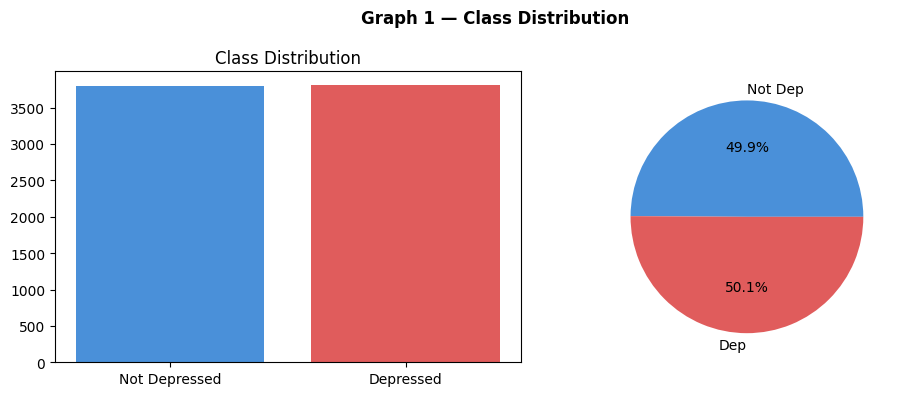

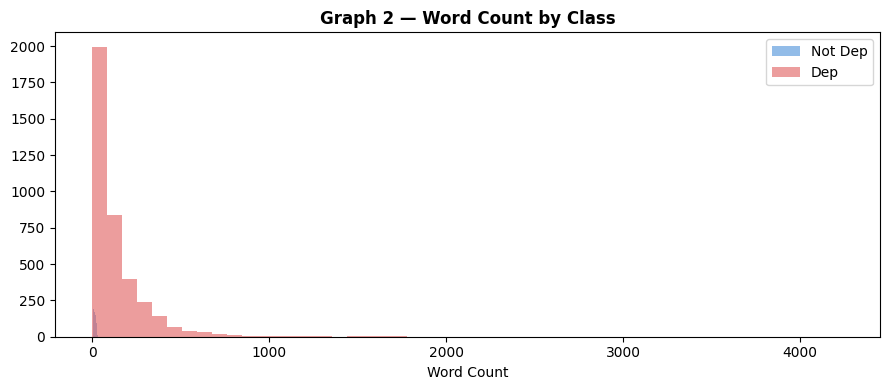

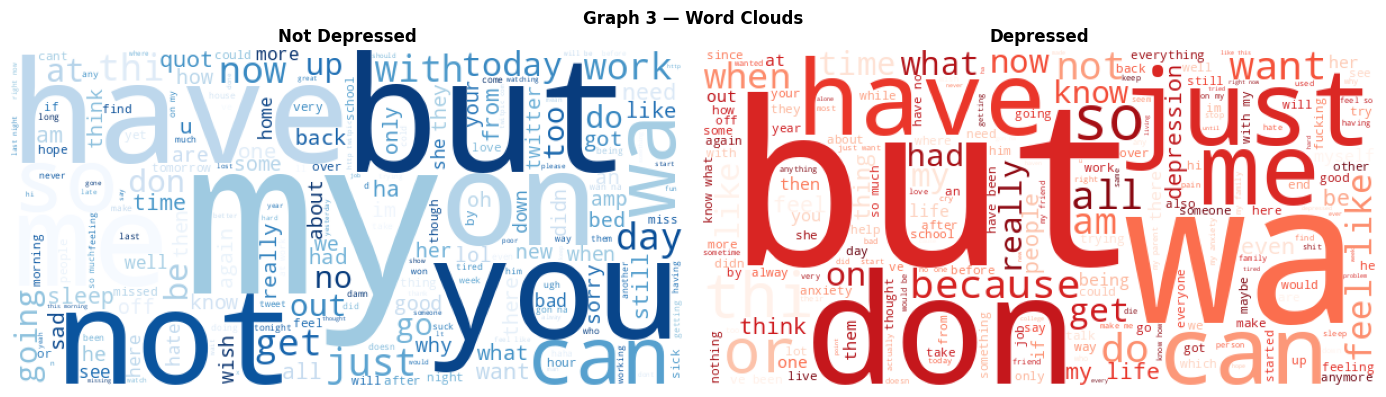

✔ EDA done

✔ Severity distribution:
severity
Moderate     6063
Mild/None    1459
Severe         80
Name: count, dtype: int64
✔ Train:5,321 Val:1,140 Test:1,141

✔ Baseline (TF-IDF + LR):
               precision    recall  f1-score   support

Not Depressed       0.94      0.99      0.96       569
    Depressed       0.99      0.94      0.96       572

     accuracy                           0.96      1141
    macro avg       0.96      0.96      0.96      1141
 weighted avg       0.96      0.96      0.96      1141

  AUC-ROC: 0.9891  F1: 0.9623


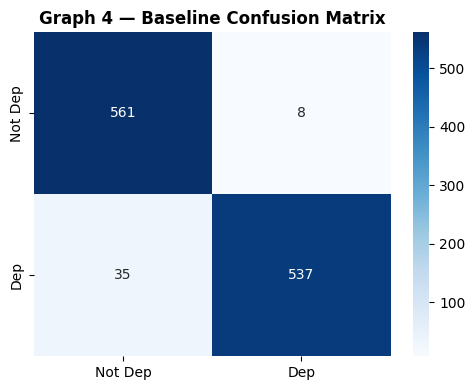


✔ Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

✔ Datasets ready


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✔ Model ready (109M params)

✔ Training (3 epochs)...
  Epoch 1 Step 50/333 Loss=0.6258
  Epoch 1 Step 100/333 Loss=0.4655
  Epoch 1 Step 150/333 Loss=0.3510
  Epoch 1 Step 200/333 Loss=0.2864
  Epoch 1 Step 250/333 Loss=0.2536
  Epoch 1 Step 300/333 Loss=0.2273
  ✔ Epoch 1 done — Val F1=0.9781 AUC=0.9973
  Epoch 2 Step 50/333 Loss=0.0335
  Epoch 2 Step 100/333 Loss=0.0441
  Epoch 2 Step 150/333 Loss=0.0472
  Epoch 2 Step 200/333 Loss=0.0450
  Epoch 2 Step 250/333 Loss=0.0412
  Epoch 2 Step 300/333 Loss=0.0468
  ✔ Epoch 2 done — Val F1=0.9807 AUC=0.9970
  Epoch 3 Step 50/333 Loss=0.0136
  Epoch 3 Step 100/333 Loss=0.0164
  Epoch 3 Step 150/333 Loss=0.0176
  Epoch 3 Step 200/333 Loss=0.0173
  Epoch 3 Step 250/333 Loss=0.0163
  Epoch 3 Step 300/333 Loss=0.0149
  ✔ Epoch 3 done — Val F1=0.9816 AUC=0.9974
✔ Training done in 6.2 min

✔ BERT Results:
               precision    recall  f1-score   support

Not Depressed       0.98      0.97      0.98       569
    Depressed       0.97      0.

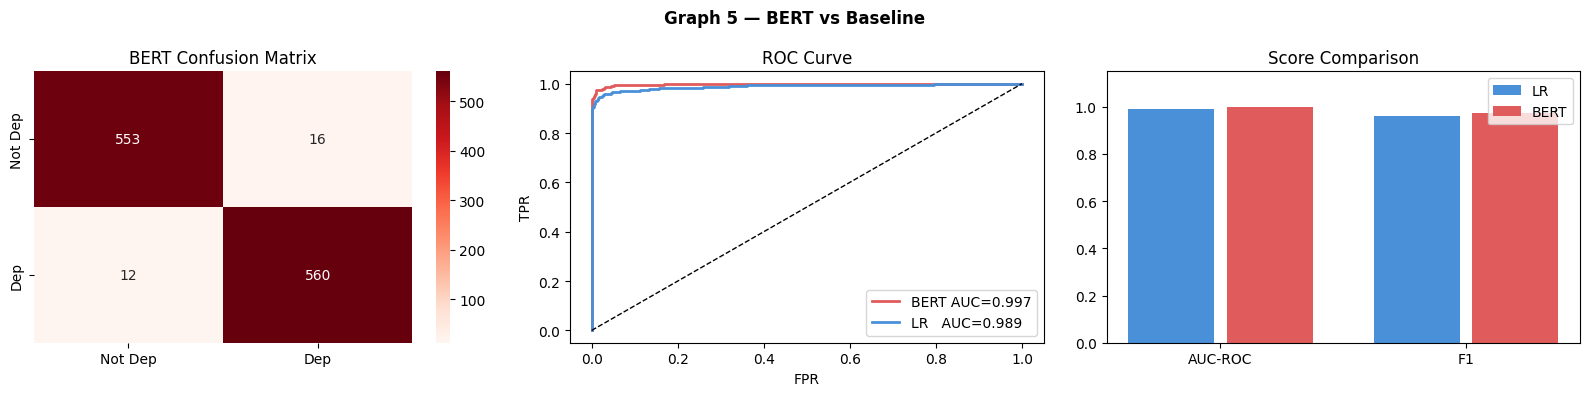


  Samples  : 7,602
  Baseline : AUC=0.9891  F1=0.9623
  BERT     : AUC=0.9972  F1=0.9755
  Severity : ✔  |  Model saved: ✔
  ALL DONE ✔


In [9]:
# ============================================================
# DEPRESSION SENTIMENT ANALYSIS — NO TRAINER VERSION
# Works on any Colab regardless of accelerate version
# ============================================================

# ── STEP 0: INSTALL ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(["pip", "install", "-q",
    "transformers", "scikit-learn", "imbalanced-learn",
    "seaborn", "wordcloud"], check=True)

# ── IMPORTS ──────────────────────────────────────────────────
import os, warnings, time
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# ✅ Only import tokenizer + model — NO Trainer, NO accelerate
from transformers import BertTokenizerFast, BertForSequenceClassification
from transformers import get_linear_schedule_with_warmup

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✔ Device: {DEVICE.upper()}")

# ── CONFIG ───────────────────────────────────────────────────
DRIVE_PATH = "/content/drive/MyDrive/depression_dataset_reddit_cleaned.csv"
TEXT_COL   = "clean_text"
LABEL_COL  = "is_depression"
MODEL_NAME = "bert-base-uncased"
MAX_LEN    = 128
BATCH_SIZE = 16
EPOCHS     = 3
LR         = 2e-5
SEED       = 42
SAVE_PATH  = "/content/drive/MyDrive/bert_depression_model/"

torch.manual_seed(SEED)
np.random.seed(SEED)

# ── LOAD DATA ────────────────────────────────────────────────
df = pd.read_csv(DRIVE_PATH)
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df = df[df[TEXT_COL].str.len() > 15].reset_index(drop=True)
print(f"✔ Loaded: {len(df):,} rows")
print(df[LABEL_COL].value_counts())

# ── EDA ──────────────────────────────────────────────────────
df["word_count"] = df[TEXT_COL].apply(lambda x: len(str(x).split()))
vc = df[LABEL_COL].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["Not Depressed","Depressed"], [vc.get(0,0), vc.get(1,0)],
            color=["#4A90D9","#E05C5C"])
axes[0].set_title("Class Distribution")
axes[1].pie([vc.get(0,0), vc.get(1,0)], labels=["Not Dep","Dep"],
            colors=["#4A90D9","#E05C5C"], autopct="%1.1f%%")
plt.suptitle("Graph 1 — Class Distribution", fontweight="bold")
plt.tight_layout(); plt.savefig("graph1.png", dpi=120); plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
for lbl, color, name in [(0,"#4A90D9","Not Dep"),(1,"#E05C5C","Dep")]:
    ax.hist(df[df[LABEL_COL]==lbl]["word_count"],
            bins=50, alpha=0.6, color=color, label=name)
ax.set_title("Graph 2 — Word Count by Class", fontweight="bold")
ax.set_xlabel("Word Count"); ax.legend()
plt.tight_layout(); plt.savefig("graph2.png", dpi=120); plt.show()

STOP = {"t","s","m","i","the","a","and","to","of","in","is","that","for","it"}
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, lbl, cmap, title in [(axes[0],0,"Blues","Not Depressed"),
                               (axes[1],1,"Reds","Depressed")]:
    corpus = " ".join(df[df[LABEL_COL]==lbl][TEXT_COL].astype(str))
    wc = WordCloud(width=600, height=300, background_color="white",
                   colormap=cmap, stopwords=STOP).generate(corpus)
    ax.imshow(wc); ax.axis("off"); ax.set_title(title, fontweight="bold")
plt.suptitle("Graph 3 — Word Clouds", fontweight="bold")
plt.tight_layout(); plt.savefig("graph3.png", dpi=120); plt.show()
print("✔ EDA done")

# ── SEVERITY ─────────────────────────────────────────────────
SEVERE_WORDS = {"suicide","hopeless","worthless","want to die",
                "empty","numb","self harm","cutting","give up","hate myself"}

def severity_score(text):
    t    = str(text).lower()
    hits = sum(1 for w in SEVERE_WORDS if w in t)
    wlen = len(t.split())
    if hits >= 3 or (hits >= 1 and wlen < 40): return "Severe"
    elif hits == 1 or wlen < 80:               return "Moderate"
    return "Mild/None"

df["severity"] = df[TEXT_COL].apply(severity_score)
print("\n✔ Severity distribution:")
print(df["severity"].value_counts())

# ── SPLIT ────────────────────────────────────────────────────
X = df[TEXT_COL].values
y = df[LABEL_COL].values.astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)
print(f"✔ Train:{len(X_train):,} Val:{len(X_val):,} Test:{len(X_test):,}")

# ── TF-IDF BASELINE ──────────────────────────────────────────
tfidf   = TfidfVectorizer(max_features=15000, ngram_range=(1,2),
                           sublinear_tf=True, min_df=2)
X_tr_tf = tfidf.fit_transform(X_train)
X_te_tf = tfidf.transform(X_test)

X_res, y_res = SMOTE(random_state=SEED).fit_resample(X_tr_tf, y_train)
lr_model     = LogisticRegression(max_iter=1000, random_state=SEED)
lr_model.fit(X_res, y_res)
y_pred_lr = lr_model.predict(X_te_tf)
y_prob_lr = lr_model.predict_proba(X_te_tf)[:,1]
auc_lr    = roc_auc_score(y_test, y_prob_lr)
f1_lr     = f1_score(y_test, y_pred_lr, average="weighted")

print("\n✔ Baseline (TF-IDF + LR):")
print(classification_report(y_test, y_pred_lr,
      target_names=["Not Depressed","Depressed"]))
print(f"  AUC-ROC: {auc_lr:.4f}  F1: {f1_lr:.4f}")

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d",
            cmap="Blues", xticklabels=["Not Dep","Dep"],
            yticklabels=["Not Dep","Dep"], ax=ax)
ax.set_title("Graph 4 — Baseline Confusion Matrix", fontweight="bold")
plt.tight_layout(); plt.savefig("graph4.png", dpi=120); plt.show()

# ── TOKENIZER + DATASET ──────────────────────────────────────
print(f"\n✔ Loading tokenizer...")
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

class RedditDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc    = tokenizer(list(texts), truncation=True, padding=True,
                                max_length=MAX_LEN, return_tensors="pt")
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.enc.items()}
        item["labels"] = self.labels[idx]
        return item

train_loader = DataLoader(RedditDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(RedditDataset(X_val,   y_val),
                          batch_size=BATCH_SIZE)
test_loader  = DataLoader(RedditDataset(X_test,  y_test),
                          batch_size=BATCH_SIZE)
print("✔ Datasets ready")

# ── LOAD BERT ────────────────────────────────────────────────
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(DEVICE)
print(f"✔ Model ready ({sum(p.numel() for p in model.parameters())/1e6:.0f}M params)")

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer,
                num_warmup_steps=100, num_training_steps=total_steps)

# ── MANUAL TRAINING LOOP ─────────────────────────────────────
def evaluate(loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            token_type_ids = batch.get("token_type_ids", None)
            labels         = batch["labels"]
            if token_type_ids is not None:
                out = model(input_ids, attention_mask=attention_mask,
                            token_type_ids=token_type_ids.to(DEVICE))
            else:
                out = model(input_ids, attention_mask=attention_mask)
            probs  = torch.softmax(out.logits, dim=-1)[:,1].cpu().numpy()
            preds  = np.argmax(out.logits.cpu().numpy(), axis=-1)
            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

print(f"\n✔ Training ({EPOCHS} epochs)...")
t0 = time.time()

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for step, batch in enumerate(train_loader):
        optimizer.zero_grad()
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        token_type_ids = batch.get("token_type_ids", None)
        labels         = batch["labels"].to(DEVICE)
        if token_type_ids is not None:
            out = model(input_ids, attention_mask=attention_mask,
                        token_type_ids=token_type_ids.to(DEVICE), labels=labels)
        else:
            out = model(input_ids, attention_mask=attention_mask, labels=labels)
        out.loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += out.loss.item()
        if (step+1) % 50 == 0:
            print(f"  Epoch {epoch+1} Step {step+1}/{len(train_loader)} "
                  f"Loss={total_loss/(step+1):.4f}")

    val_labels, val_preds, val_probs = evaluate(val_loader)
    val_f1  = f1_score(val_labels, val_preds, average="weighted")
    val_auc = roc_auc_score(val_labels, val_probs)
    print(f"  ✔ Epoch {epoch+1} done — Val F1={val_f1:.4f} AUC={val_auc:.4f}")

print(f"✔ Training done in {(time.time()-t0)/60:.1f} min")

# ── EVALUATE ON TEST ─────────────────────────────────────────
y_test_arr, y_pred_bert, y_prob_bert = evaluate(test_loader)
auc_bert = roc_auc_score(y_test_arr, y_prob_bert)
f1_bert  = f1_score(y_test_arr, y_pred_bert, average="weighted")

print("\n✔ BERT Results:")
print(classification_report(y_test_arr, y_pred_bert,
      target_names=["Not Depressed","Depressed"]))
print(f"  AUC-ROC: {auc_bert:.4f}  F1: {f1_bert:.4f}")

# ── GRAPHS ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Graph 5 — BERT vs Baseline", fontweight="bold")

sns.heatmap(confusion_matrix(y_test_arr, y_pred_bert), annot=True, fmt="d",
            cmap="Reds", xticklabels=["Not Dep","Dep"],
            yticklabels=["Not Dep","Dep"], ax=axes[0])
axes[0].set_title("BERT Confusion Matrix")

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_b,  tpr_b,  _ = roc_curve(y_test_arr, y_prob_bert)
axes[1].plot(fpr_b,  tpr_b,  "#E05C5C", lw=2, label=f"BERT AUC={auc_bert:.3f}")
axes[1].plot(fpr_lr, tpr_lr, "#4A90D9", lw=2, label=f"LR   AUC={auc_lr:.3f}")
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].set_title("ROC Curve"); axes[1].legend()
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")

x = np.arange(2)
axes[2].bar(x-0.2, [auc_lr,  f1_lr],   0.35, label="LR",   color="#4A90D9")
axes[2].bar(x+0.2, [auc_bert, f1_bert], 0.35, label="BERT", color="#E05C5C")
axes[2].set_xticks(x); axes[2].set_xticklabels(["AUC-ROC","F1"])
axes[2].set_ylim(0,1.15); axes[2].legend(); axes[2].set_title("Score Comparison")
plt.tight_layout(); plt.savefig("graph5.png", dpi=120); plt.show()

# ── SAVE ─────────────────────────────────────────────────────
os.makedirs(SAVE_PATH, exist_ok=True)
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("\n" + "="*50)
print(f"  Samples  : {len(df):,}")
print(f"  Baseline : AUC={auc_lr:.4f}  F1={f1_lr:.4f}")
print(f"  BERT     : AUC={auc_bert:.4f}  F1={f1_bert:.4f}")
print(f"  Severity : ✔  |  Model saved: ✔")
print("="*50)
print("  ALL DONE ✔")
print("="*50)